# LaCAM + PIBT + primitive demo
This notebook runs the planner once, retains every anytime incumbent, and lets you compare smooth/waypoint-only animations without searching again.

In [22]:
from pathlib import Path    
import subprocess, sys, yaml
from IPython.display import Image, display
REPO = Path('..').resolve()
sys.path.insert(0, str(REPO / 'python'))
from lacam_primitive_viz import plan_and_animate

In [23]:
subprocess.run(['cmake', '-S', str(REPO), '-B', str(REPO / 'build'), '-DCMAKE_BUILD_TYPE=Release'], check=True)
subprocess.run(['cmake', '--build', str(REPO / 'build'), '-j2'], check=True)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kakitsu/tel/lacam_primitive/build
[ 60%] Built target lacam_primitive_core
[ 80%] Built target lacam_primitive
[100%] Built target lacam_primitive_tests


CompletedProcess(args=['cmake', '--build', '/home/kakitsu/tel/lacam_primitive/build', '-j2'], returncode=0)

In [53]:
time_limit_ms = 50000
transition_cache = True
candidate_cache = True
ara_star = True

transition_cache = False
candidate_cache = False
ara_star = False

collision_mode = "time_indexed"  # or "whole_step"
max_boundary_travel_per_interval_m = 0.005  # 5 mm

# Physical-size scale: changing cell_size no longer changes the canvas size.
pixels_per_meter = 240

artifacts = plan_and_animate(
    REPO,
    REPO / 'examples' / 'example.yaml',
    REPO / "outputs" / "notebook_rotation_pivot",
    time_limit_ms=time_limit_ms,
    transition_cache=transition_cache,
    candidate_cache=candidate_cache,
    ara_star=ara_star,
    collision_mode=collision_mode,
    max_boundary_travel_per_interval_m=max_boundary_travel_per_interval_m,
    pixels_per_meter=pixels_per_meter,
    animation_modes=("smooth", "waypoints"),
    include_all_solutions=True,
)

solution improved: cost=2.4 weight=10 search_ms=1440.37
precompute static: 14.222 ms (primitive/collision=14.222, transition_cache=0)
precompute query: 0.031294 ms (candidate_cache=0)
search: 50001.4 ms
warm request: 50001.5 ms
cold total: 50015.7 ms
modes: transition_cache=off candidate_cache=off ara_star=off collision_mode=time_indexed max_boundary_travel_per_interval_m=0.005 collision_intervals=231
cache stats: transition 0/25916031 hits, candidate 0/852294 hits, expanded_nodes=11413
Final solution cost: 2.4, search: 50001.4 ms



In [54]:
[(item['solution_index'], item['cost'], item['weight'], item['mode'])
 for item in artifacts['animations']]

[(0, 2.4, 10, 'smooth'), (0, 2.4, 10, 'waypoints')]

'cost=2.4, weight=10, found at 1440.3 ms'

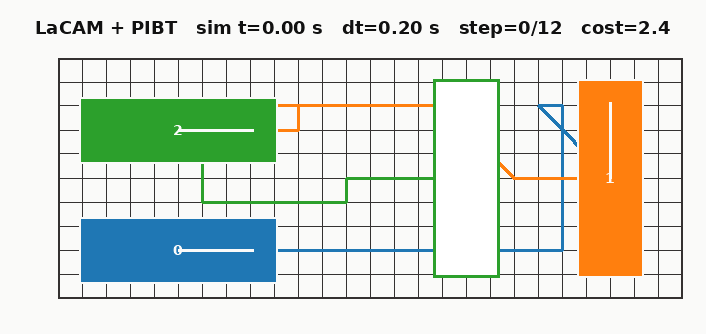

In [55]:
# Select an incumbent and rendering mode without rerunning the planner.
#animation_mode = "smooth"  # or "waypoints"
animation_mode = "waypoints"
available = [item for item in artifacts['animations']
             if item['mode'] == animation_mode]
selected = available[-1]  # -1: lowest-cost incumbent, 0: first incumbent
display(f"cost={selected['cost']}, weight={selected['weight']}, "
        f"found at {selected['elapsed_ms']:.1f} ms")
display(Image(filename=str(selected['path'])))

In [7]:
selected

{'solution_index': 2,
 'cost': 1.8,
 'weight': 1.5,
 'elapsed_ms': 3376.663358,
 'mode': 'waypoints',
 'path': PosixPath('/home/kakitsu/tel/lacam_primitive/outputs/notebook/solution_02_cost_1p8_waypoints.gif')}

In [8]:
with artifacts['solution'].open(encoding='utf-8') as stream:
    result = yaml.safe_load(stream)
([(item['elapsed_ms'], item['cost'], item['weight'])
  for item in result['improvements']],
 result['cost'])

([(1747.675667, 3.4, 10), (1931.747379, 2.4, 3), (3376.663358, 1.8, 1.5)], 1.8)